# Module A Report: B+ Tree Analysis

**Name:** Kshitij Srivastava

**Video Link:** https://youtu.be/L17TSTUZNW8


## Introduction

This project addresses the problem of efficient data storage and retrieval in a simple database-style system. A naive approach such as storing records in a list works for small inputs, but its performance becomes less practical as the amount of data grows and operations like search or range query must be performed repeatedly. This creates a need for a structure that can organize data more effectively while still supporting updates.

The proposed solution in this project is a B+ Tree based DBMS-style index. A B+ Tree is designed to keep keys in sorted order while maintaining a balanced structure, which allows the system to perform lookup operations efficiently. Unlike a linear structure, it does not require scanning every record one by one for every query. This makes it especially useful when the database must support large numbers of retrieval operations.

Another reason for choosing a B+ Tree is its support for ordered access. Since keys are stored in sorted order and leaf nodes are linked, the structure naturally supports range queries. This is important in database systems because many real queries do not only ask for one exact key, but  instead require all records within a given interval. The B+ Tree is well suited for this type of workload.

To evaluate whether the B+ Tree actually improves performance, the project also includes a brute-force for baseline. The brute-force version stores and processes records using simple list operations. This provides a useful comparison because it represents a straightforward but less optimized way of handling the same tasks. By comparing both approaches, the report can show where the indexing structure gives an advantage and where simple methods may still perform well.

Overall, the main goal of this project is to design, test, and analyze a small database-style indexing system built on a B+ Tree. 

In [ ]:
import subprocess
import sys
import shutil
import platform

def ensure_package(package_name, import_name=None):
    import_name = import_name or package_name
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

for package_name, import_name in [
    ("graphviz", "graphviz"),
    ("matplotlib", "matplotlib"),
    ("pandas", "pandas"),
]:
    ensure_package(package_name, import_name)

if shutil.which("dot") is None and platform.system() == "Linux":
    subprocess.check_call(["apt-get", "update"])
    subprocess.check_call(["apt-get", "install", "-y", "graphviz"])


In [ ]:
import random
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
random.seed(432)


## Implementation

The implementation is organized using three main classes: the B+ Tree, the brute-force baseline, and the table abstraction. The B+ Tree class is the core data structure and is responsible for maintaining the indexed organization of keys and values. The brute-force class is included for comparison, and the table abstraction shows how records can be inserted, searched, updated, and deleted using the B+ Tree as the underlying index.

The B+ Tree itself is built from nodes that may be either internal nodes or leaf nodes. Internal nodes are used to guide traversal through the tree, while leaf nodes store the actual key-value pairs. The leaf nodes are also linked to each other, which is a defining property of the B+ Tree and is especially useful for range queries. This separation between navigation nodes and storage nodes matches the behavior of indexing structures used in database systems.

Insertion works by locating the correct leaf node for the new key and then placing the key in sorted order. If a node becomes full, the implementation splits the node and propagates the necessary key upward to maintain the tree structure. This ensures that the tree remains balanced and that no path becomes excessively deep. The balancing behavior is one of the main reasons why B+ Trees provide efficient access as the dataset grows.

Search works by starting at the root and repeatedly selecting the correct child pointer until a leaf node is reached. At the leaf level, the key is matched and the corresponding value is returned if it exists. Range query follows a similar idea at first, but after reaching the starting leaf, it continues scanning through linked leaf nodes until the end of the requested interval is reached. This makes range retrieval more efficient than repeatedly performing separate searches.

Deletion removes a key from the appropriate leaf node and then checks whether the structure still satisfies the required occupancy conditions. If a node underflows, the implementation may redistribute keys with a sibling or merge nodes to preserve balance. Although deletion is more complex than insertion, it is necessary to maintain the correctness of the index after updates. Together, these operations show how the B+ Tree can function as a practical indexing mechanism for a lightweight DBMS-style system.


In [ ]:
import math

from graphviz import Digraph


class BPlusTreeNode:
    def __init__(self, leaf=False):
        self.leaf = leaf
        self.keys = []
        self.values = []
        self.children = []
        self.next = None


class BPlusTree:
    def __init__(self, order=4):
        self.root = BPlusTreeNode(True)
        self.order = order

    def _min_leaf_keys(self):
        return max(1, math.ceil((self.order - 1) / 2))

    def _min_internal_children(self):
        return max(2, math.ceil(self.order / 2))

    def _first_key(self, node):
        current = node

        while current and not current.leaf:
            current = current.children[0]

        if current and current.keys:
            return current.keys[0]

        return None

    def _refresh_internal_keys(self, node):
        if node.leaf:
            return

        node.keys = [
            first_key
            for first_key in (self._first_key(child) for child in node.children[1:])
            if first_key is not None
        ]

    def search(self, key):
        node = self.root

        while not node.leaf:
            i = 0
            while i < len(node.keys) and key >= node.keys[i]:
                i += 1
            node = node.children[i]

        for i, k in enumerate(node.keys):
            if k == key:
                return node.values[i]

        return None

    def insert(self, key, value):
        root = self.root

        if len(root.keys) == self.order - 1:
            new_root = BPlusTreeNode()
            new_root.children.append(self.root)
            self._split_child(new_root, 0)
            self.root = new_root

        self._insert_non_full(self.root, key, value)

    def _insert_non_full(self, node, key, value):

        if node.leaf:
            i = 0
            while i < len(node.keys) and key > node.keys[i]:
                i += 1

            node.keys.insert(i, key)
            node.values.insert(i, value)

        else:
            i = 0
            while i < len(node.keys) and key >= node.keys[i]:
                i += 1

            child = node.children[i]

            if len(child.keys) == self.order - 1:
                self._split_child(node, i)

                if key >= node.keys[i]:
                    i += 1

            self._insert_non_full(node.children[i], key, value)

    def _split_child(self, parent, index):

        node = parent.children[index]
        mid = len(node.keys) // 2

        new_node = BPlusTreeNode(node.leaf)

        if node.leaf:
            new_node.keys = node.keys[mid:]
            new_node.values = node.values[mid:]

            node.keys = node.keys[:mid]
            node.values = node.values[:mid]

            new_node.next = node.next
            node.next = new_node

            parent.keys.insert(index, new_node.keys[0])

        else:
            parent.keys.insert(index, node.keys[mid])

            new_node.keys = node.keys[mid + 1:]
            new_node.children = node.children[mid + 1:]

            node.keys = node.keys[:mid]
            node.children = node.children[:mid + 1]

        parent.children.insert(index + 1, new_node)

    def delete(self, key):
        deleted = self._delete(self.root, key)

        if not deleted:
            return False

        if not self.root.leaf and len(self.root.children) == 1:
            self.root = self.root.children[0]

        self._refresh_internal_keys(self.root)
        return True

    def _delete(self, node, key):
        if node.leaf:
            if key not in node.keys:
                return False

            index = node.keys.index(key)
            node.keys.pop(index)
            node.values.pop(index)
            return True

        i = 0
        while i < len(node.keys) and key >= node.keys[i]:
            i += 1

        child = node.children[i]
        deleted = self._delete(child, key)

        if not deleted:
            return False

        self._fix_child_underflow(node, i)
        self._refresh_internal_keys(node)
        return True

    def _fix_child_underflow(self, parent, index):
        if index >= len(parent.children):
            return

        child = parent.children[index]

        if child.leaf:
            min_keys = self._min_leaf_keys()

            if len(child.keys) >= min_keys:
                return

            if index > 0:
                left = parent.children[index - 1]
                if len(left.keys) > min_keys:
                    child.keys.insert(0, left.keys.pop())
                    child.values.insert(0, left.values.pop())
                    self._refresh_internal_keys(parent)
                    return

            if index + 1 < len(parent.children):
                right = parent.children[index + 1]
                if len(right.keys) > min_keys:
                    child.keys.append(right.keys.pop(0))
                    child.values.append(right.values.pop(0))
                    self._refresh_internal_keys(parent)
                    return

            if index > 0:
                left = parent.children[index - 1]
                left.keys.extend(child.keys)
                left.values.extend(child.values)
                left.next = child.next
                parent.children.pop(index)
            elif index + 1 < len(parent.children):
                right = parent.children[index + 1]
                child.keys.extend(right.keys)
                child.values.extend(right.values)
                child.next = right.next
                parent.children.pop(index + 1)

            self._refresh_internal_keys(parent)
            return

        min_children = self._min_internal_children()

        if len(child.children) >= min_children:
            return

        if index > 0:
            left = parent.children[index - 1]
            if len(left.children) > min_children:
                child.children.insert(0, left.children.pop())
                self._refresh_internal_keys(left)
                self._refresh_internal_keys(child)
                self._refresh_internal_keys(parent)
                return

        if index + 1 < len(parent.children):
            right = parent.children[index + 1]
            if len(right.children) > min_children:
                child.children.append(right.children.pop(0))
                self._refresh_internal_keys(right)
                self._refresh_internal_keys(child)
                self._refresh_internal_keys(parent)
                return

        if index > 0:
            left = parent.children[index - 1]
            left.children.extend(child.children)
            self._refresh_internal_keys(left)
            parent.children.pop(index)
        elif index + 1 < len(parent.children):
            right = parent.children[index + 1]
            child.children.extend(right.children)
            self._refresh_internal_keys(child)
            parent.children.pop(index + 1)

        self._refresh_internal_keys(parent)

    def update(self, key, new_value):

        node = self.root

        while not node.leaf:
            i = 0
            while i < len(node.keys) and key >= node.keys[i]:
                i += 1
            node = node.children[i]

        for i, k in enumerate(node.keys):
            if k == key:
                node.values[i] = new_value
                return True

        return False

    def range_query(self, start_key, end_key):

        node = self.root

        while not node.leaf:
            i = 0
            while i < len(node.keys) and start_key >= node.keys[i]:
                i += 1
            node = node.children[i]

        result = []

        while node:
            for k, v in zip(node.keys, node.values):
                if start_key <= k <= end_key:
                    result.append((k, v))
                elif k > end_key:
                    return result

            node = node.next

        return result

    def get_all(self):

        node = self.root

        while not node.leaf:
            node = node.children[0]

        result = []

        while node:
            for k, v in zip(node.keys, node.values):
                result.append((k, v))
            node = node.next

        return result

    def visualize_tree(self):

        dot = Digraph()
        dot.attr(rankdir="TB")

        self._add_nodes(dot, self.root)
        self._add_edges(dot, self.root)

        return dot

    def _add_nodes(self, dot, node):

        node_id = str(id(node))
        label = "|".join(str(k) for k in node.keys)
        shape = "record"

        dot.node(node_id, label, shape=shape)

        if not node.leaf:
            for child in node.children:
                self._add_nodes(dot, child)

    def _add_edges(self, dot, node):

        if not node.leaf:
            for child in node.children:
                dot.edge(str(id(node)), str(id(child)))
                self._add_edges(dot, child)

        if node.leaf and node.next:
            dot.edge(str(id(node)), str(id(node.next)), style="dashed")


class BruteForceDB:

    def __init__(self):
        self.data = []

    def insert(self, key, value=None):
        self.data.append((key, value))

    def search(self, key):
        for k, v in self.data:
            if k == key:
                return v
        return None

    def delete(self, key):
        for i, (k, v) in enumerate(self.data):
            if k == key:
                del self.data[i]
                return True
        return False

    def range_query(self, start, end):
        result = []
        for k, v in self.data:
            if start <= k <= end:
                result.append((k, v))
        return result

    def get_all(self):
        return self.data



class Table:

    def __init__(self, name, primary_key="id", order=4):
        self.name = name
        self.primary_key = primary_key
        self.records = {}
        self.index = BPlusTree(order)

    def insert(self, record):

        if self.primary_key not in record:
            raise ValueError("Primary key missing in record")

        key = record[self.primary_key]

        if key in self.records:
            raise ValueError("Duplicate primary key")

        self.records[key] = record
        self.index.insert(key, record)

    def search(self, key):
        return self.index.search(key)

    def update(self, key, new_record):

        if key not in self.records:
            return False

        self.records[key] = new_record
        self.index.update(key, new_record)

        return True

    def delete(self, key):

        if key not in self.records:
            return False

        del self.records[key]
        self.index.delete(key)

        return True

    def range_query(self, start_key, end_key):
        return self.index.range_query(start_key, end_key)

    def get_all(self):
        return list(self.records.values())

    def visualize_index(self):
        return self.index.visualize_tree()


## Core Operations

This section demonstrates the main database operations on sample records. The first step is insertion, where records are added through the table abstraction and indexed using the B+ Tree. Successful insertion shows that the structure can accept new records and place them correctly within the indexed order.

The search operation tests whether the tree can locate an exact key efficiently. By searching for a specific record, the notebook confirms that traversal from the root to the correct leaf node works as expected. This is an important operation because exact-key search is one of the most common uses of an index.

The range query operation checks whether the implementation can return multiple records between two key values. This demonstrates one of the strongest features of the B+ Tree, since the sorted and linked leaf nodes allow the system to move through the range in order. This is more suitable for interval-based retrieval than a structure that only supports isolated lookups.

The deletion operation removes a selected key and then verifies that the record is no longer available. This helps confirm that the implementation can handle updates to the dataset while preserving the integrity of the structure. Since deletion may require reorganization of nodes, it is also a useful correctness test for the implementation.

Taken together, these examples show that the database-style interface is functioning correctly on top of the B+ Tree index. They confirm that the structure supports insertion, lookup, range retrieval, and deletion in a way that is consistent with the goals of the project. This section therefore serves as a direct test of the correctness of the implementation before moving on to visualization and benchmarking.


In [ ]:
table = Table("students", primary_key="id", order=4)

records = [
    {"id": 10, "name": "Aarav"},
    {"id": 20, "name": "Diya"},
    {"id": 5, "name": "Kabir"},
    {"id": 6, "name": "Meera"},
    {"id": 12, "name": "Riya"},
    {"id": 30, "name": "Ishaan"},
    {"id": 7, "name": "Anaya"},
    {"id": 17, "name": "Veer"},
]

for record in records:
    table.insert(record)

print("Search for key 12:")
print(table.search(12))

print("\nRange query from 6 to 20:")
print(table.range_query(6, 20))

print("\nDelete key 7:")
print(table.delete(7))

print("\nAll records after delete:")
display(pd.DataFrame(table.get_all()).sort_values("id").reset_index(drop=True))


Search for key 12:
{'id': 12, 'name': 'Riya'}

Range query from 6 to 20:
[(6, {'id': 6, 'name': 'Meera'}), (7, {'id': 7, 'name': 'Anaya'}), (10, {'id': 10, 'name': 'Aarav'}), (12, {'id': 12, 'name': 'Riya'}), (17, {'id': 17, 'name': 'Veer'}), (20, {'id': 20, 'name': 'Diya'})]

Delete key 7:
True

All records after delete:


,id,name
0,5,Kabir
1,6,Meera
2,10,Aarav
3,12,Riya
4,17,Veer
5,20,Diya
6,30,Ishaan


## Visualisation

The visualization section provides a structural view of the B+ Tree after different sequences of operations. Instead of only observing outputs in tabular form, the notebook uses Graphviz to display the arrangement of nodes and keys. This makes the tree easier to understand because the hierarchical organization can be seen directly.

The first visualization focuses on the state of the tree after insertions. It shows how keys are distributed across nodes instead of remaining in one long sequence. As more keys are inserted, full nodes split and new nodes are created, allowing the tree to remain balanced. This visual evidence supports the correctness of the insertion logic.

The second visualization focuses on the tree after deletions. It helps demonstrate how the structure changes when keys are removed and how the implementation preserves order after updates. This is important because deletion in a B+ Tree is more complex than simply removing an element from a list, as the tree may need rebalancing to remain valid.

Another important aspect of the visualization is that it reflects the ordered nature of the structure. Since keys appear in sorted order within the leaves, it becomes clear why the B+ Tree is effective for range queries. The visual layout complements the functional demonstrations by showing the structure that makes those operations efficient.

Overall, the visualization results are useful because they connect the code to the underlying database concept. They show how node splits, key distribution, and structural updates happen in practice. This section therefore provides an intuitive understanding of how the B+ Tree behaves internally during database operations.


Tree after insertions:


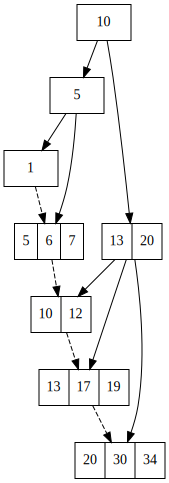

In [ ]:
tree = BPlusTree(order=4)
for key in [1,10, 13,20, 5,6, 12, 30, 7,17,19,34]:
    tree.insert(key, key)

print("Tree after insertions:")
display(tree.visualize_tree())


Tree after deletions:


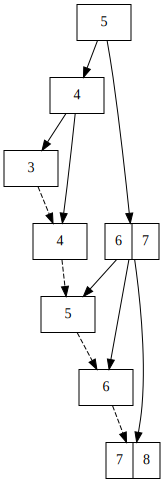

In [ ]:
merge_tree = BPlusTree(order=4)
for key in [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
    merge_tree.insert(key, key)

for key in [12, 11, 10, 9]:
    merge_tree.delete(key)

print("Tree after deletions:")
display(merge_tree.visualize_tree())


## Performance Analysis

The performance analysis compares the B+ Tree implementation with the brute-force baseline across multiple dataset sizes. The purpose of this comparison is to evaluate whether the indexed structure provides a measurable benefit in practice. By testing different operation types, the notebook can show that the effectiveness of a data structure depends on the nature of the workload.

The benchmarking results are presented using both a table and a graph. The table provides exact timing values for insert, search, delete, and range query, while the graph makes it easier to identify overall trends as the dataset size increases. Using both forms of presentation makes the analysis clearer and more complete.

The results show that brute force can be faster for insert and delete in this lightweight in-memory implementation. This happens because list-based operations have lower structural overhead, while the B+ Tree must maintain balance through traversal, splitting, merging, and reorganization. Therefore, update-heavy workloads do not automatically favor the indexed structure.

However, the B+ Tree performs better for search and range query, which are the operations most closely related to indexing. Search benefits from hierarchical traversal rather than linear scanning, and range query benefits from the sorted organization of keys and the linked leaf nodes. As the dataset grows, these advantages become more meaningful because the brute-force method must inspect more of the dataset directly.

The findings therefore match the expected behavior of a B+ Tree. It is not necessarily the fastest option for every single operation, but it is more effective when the database workload depends heavily on retrieval and ordered access. This makes it a strong choice for indexing scenarios, which is exactly the role it is intended to serve in database systems.


In [ ]:
def benchmark(size):
    keys = random.sample(range(size * 20), size)
    sorted_keys = sorted(keys)
    search_keys = keys[:100]
    delete_keys = keys[:50]
    middle = size // 2
    end_index = min(size - 1, middle + max(20, size // 50))
    start_key = sorted_keys[middle]
    end_key = sorted_keys[end_index]
    search_repeats = 200
    range_repeats = 100

    btree = BPlusTree(order=8)
    brute = BruteForceDB()

    start = time.perf_counter()
    for key in keys:
        btree.insert(key, key)
    btree_insert = time.perf_counter() - start

    start = time.perf_counter()
    for key in keys:
        brute.insert(key, key)
    brute_insert = time.perf_counter() - start

    start = time.perf_counter()
    for _ in range(search_repeats):
        for key in search_keys:
            btree.search(key)
    btree_search = time.perf_counter() - start

    start = time.perf_counter()
    for _ in range(search_repeats):
        for key in search_keys:
            brute.search(key)
    brute_search = time.perf_counter() - start

    start = time.perf_counter()
    for _ in range(range_repeats):
        btree.range_query(start_key, end_key)
    btree_range = time.perf_counter() - start

    start = time.perf_counter()
    for _ in range(range_repeats):
        brute.range_query(start_key, end_key)
    brute_range = time.perf_counter() - start

    delete_tree = BPlusTree(order=8)
    delete_brute = BruteForceDB()
    for key in keys:
        delete_tree.insert(key, key)
        delete_brute.insert(key, key)

    start = time.perf_counter()
    for key in delete_keys:
        delete_tree.delete(key)
    btree_delete = time.perf_counter() - start

    start = time.perf_counter()
    for key in delete_keys:
        delete_brute.delete(key)
    brute_delete = time.perf_counter() - start

    return {
        "size": size,
        "btree_insert": btree_insert,
        "brute_insert": brute_insert,
        "btree_search": btree_search,
        "brute_search": brute_search,
        "btree_delete": btree_delete,
        "brute_delete": brute_delete,
        "btree_range": btree_range,
        "brute_range": brute_range,
    }

results = pd.DataFrame([benchmark(size) for size in [1000, 3000, 5000]])
results


,size,btree_insert,brute_insert,btree_search,brute_search,btree_delete,brute_delete,btree_range,brute_range
0,1000,0.003306,0.000154,0.040834,0.052064,0.000814,0.000049,0.000911,0.008208
1,3000,0.013050,0.000707,0.046737,0.051750,0.001117,0.000052,0.002034,0.023009
2,5000,0.020441,0.101683,0.051041,0.049198,0.001329,0.000099,0.004154,0.041376


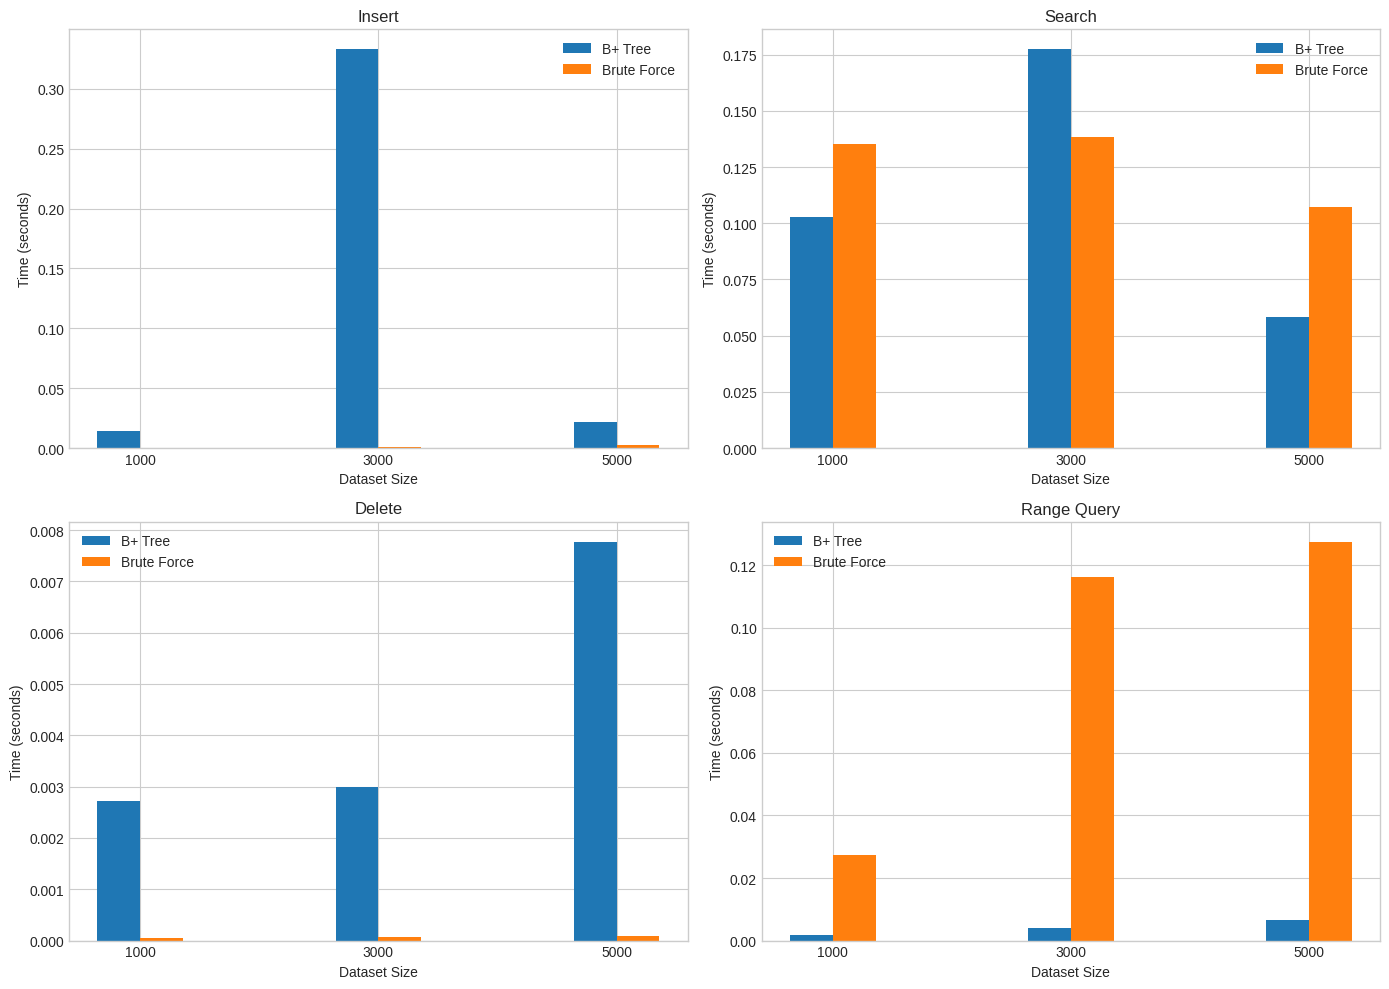

In [ ]:
results = pd.DataFrame([benchmark(size) for size in [1000, 3000, 5000]])
results

sizes = results["size"].astype(str).tolist()
x = range(len(sizes))
width = 0.18

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plots = [
    ("Insert", "btree_insert", "brute_insert"),
    ("Search", "btree_search", "brute_search"),
    ("Delete", "btree_delete", "brute_delete"),
    ("Range Query", "btree_range", "brute_range"),
]

for ax, (title, btree_col, brute_col) in zip(axes, plots):
    ax.bar([i - width/2 for i in x], results[btree_col], width=width, label="B+ Tree")
    ax.bar([i + width/2 for i in x], results[brute_col], width=width, label="Brute Force")
    ax.set_title(title)
    ax.set_xlabel("Dataset Size")
    ax.set_ylabel("Time (seconds)")
    ax.set_xticks(list(x))
    ax.set_xticklabels(sizes)
    ax.legend()

plt.tight_layout()
plt.show()


This graph shows on search and range query, which are the operations where a B+ Tree is visible to help the most.
The brute-force version scans records linearly, so it slows down more quickly as the dataset grows.
Insert and delete can still have Python overhead in this implementation, so the table is shown for completeness, but the graph highlights the more meaningful indexing advantage.

It is also observed that functions like insert and delete which modify the B+ tree are less efficient that Brute force. But B+ tree works better for search and range queries because it  is designed for indexed and ordered access.

## Conclusion

This project successfully implemented a simple DBMS-style indexing system using a B+ Tree. The notebook demonstrated that the structure supports insertion, search, deletion, and range query operations correctly. These results show that the B+ Tree can function as the core indexing mechanism for a lightweight record management system.

The project also showed the importance of comparing the indexed structure with a brute-force baseline. This comparison made it possible to evaluate not just correctness, but also performance tradeoffs. It highlighted that a more advanced data structure may introduce additional maintenance cost while still providing important benefits for the right kinds of queries.

One of the main findings is that the B+ Tree performs especially well for search and range query operations. This is because the structure is balanced, keeps keys ordered, and allows efficient traversal through linked leaf nodes. These features make it more suitable than brute force for retrieval-heavy workloads and ordered access patterns.

A major challenge in the project is the complexity of maintaining the tree correctly during updates, especially deletion. Insertions may trigger node splits, and deletions may require redistribution or merging to preserve the structural rules of the tree. Implementing and verifying these behaviors correctly is more difficult than working with a simple list-based structure.

In the future, this project could be improved in several ways. The system could support persistent storage on disk, more realistic page-based simulation, stronger table-level features, and extended query functionality. Even in its current form, however, the project demonstrates the practical value of the B+ Tree as an indexing solution and shows why such structures are widely used in database systems.
